### Student Name:Abdullah Abudahab                
### ID:2401245052

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

---
## Task 1 — Exploratory Data Analysis (EDA)

### Number of rows and columns :

In [4]:
df = pd.read_csv('car_price.csv')
df.columns = [c.strip().lower() for c in df.columns]

print(f'Rows   : {df.shape[0]}')
print(f'Columns: {df.shape[1]}')
df.head()

Rows   : 72435
Columns: 10


,model,year,price,transmission,mileage,fueltype,tax,mpg,enginesize,make
0,A1,2017.0,12500.0,Manual,15735.0,Petrol,150.0,55.4,1.4,audi
1,A6,2016.0,16500.0,Automatic,36203.0,Diesel,20.0,64.2,2.0,audi
2,A1,2016.0,11000.0,Manual,29946.0,Petrol,30.0,55.4,1.4,audi
3,A4,2017.0,16800.0,Automatic,25952.0,Diesel,145.0,67.3,2.0,audi
4,A3,2019.0,17300.0,Manual,1998.0,Petrol,145.0,49.6,1.0,audi


### Feature Types

In [5]:
numerical   = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical = df.select_dtypes(include=['object']).columns.tolist()

print('Numerical features  :', numerical)
print('Categorical features:', categorical)
print()
print(df.dtypes)

Numerical features  : ['year', 'price', 'mileage', 'tax', 'mpg', 'enginesize']
Categorical features: ['model', 'transmission', 'fueltype', 'make']

model            object
year            float64
price           float64
transmission     object
mileage         float64
fueltype         object
tax             float64
mpg             float64
enginesize      float64
make             object
dtype: object


### Missing Values

In [6]:
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df  = pd.DataFrame({'Count': missing, 'Percentage (%)': missing_pct})
missing_df  = missing_df[missing_df['Count'] > 0].sort_values('Count', ascending=False)
missing_df

,Count,Percentage (%)
transmission,3623,5.0
year,3622,5.0
fueltype,3622,5.0
mileage,3622,5.0
enginesize,3622,5.0
model,3621,5.0
price,3621,5.0
tax,3621,5.0
mpg,3621,5.0
make,3621,5.0


### 1.4 Price Distribution

count     68814.000000
mean      16583.919261
std        9304.412707
min         495.000000
25%       10167.250000
50%       14495.000000
75%       20359.750000
max      145000.000000
Name: price, dtype: float64


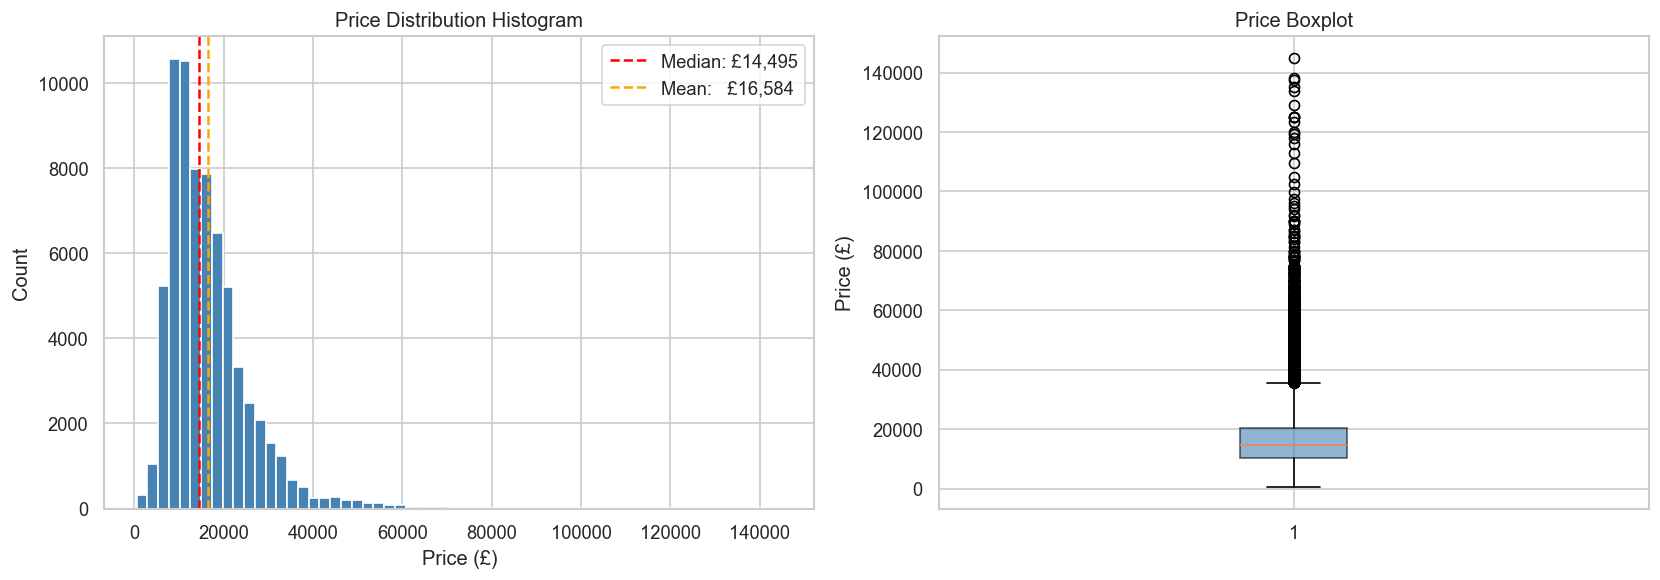

In [7]:
print(df['price'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['price'].dropna(), bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(df['price'].median(), color='red',    linestyle='--',
                label=f'Median: \u00a3{df["price"].median():,.0f}')
axes[0].axvline(df['price'].mean(),   color='orange', linestyle='--',
                label=f'Mean:   \u00a3{df["price"].mean():,.0f}')
axes[0].set_title('Price Distribution Histogram')
axes[0].set_xlabel('Price (\u00a3)')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].boxplot(df['price'].dropna(), patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Price Boxplot')
axes[1].set_ylabel('Price (\u00a3)')

plt.tight_layout()
plt.show()

### 1.5 Correlation Heatmap

Correlation with price:
price         1.000000
enginesize    0.629839
year          0.519383
tax           0.353204
mpg          -0.335615
mileage      -0.427524
Name: price, dtype: float64


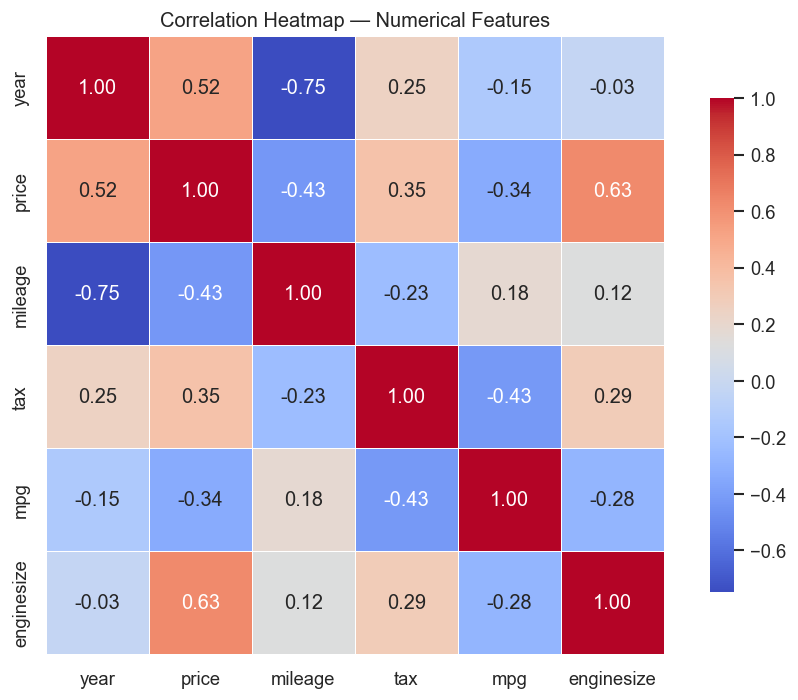

In [8]:
num_cols = ['year', 'price', 'mileage', 'tax', 'mpg', 'enginesize']
corr = df[num_cols].corr()

print('Correlation with price:')
print(corr['price'].sort_values(ascending=False))

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap — Numerical Features')
plt.tight_layout()
plt.show()
# The engine size is more related to the engine size .

### 1.6 Price by Make & Fuel Type

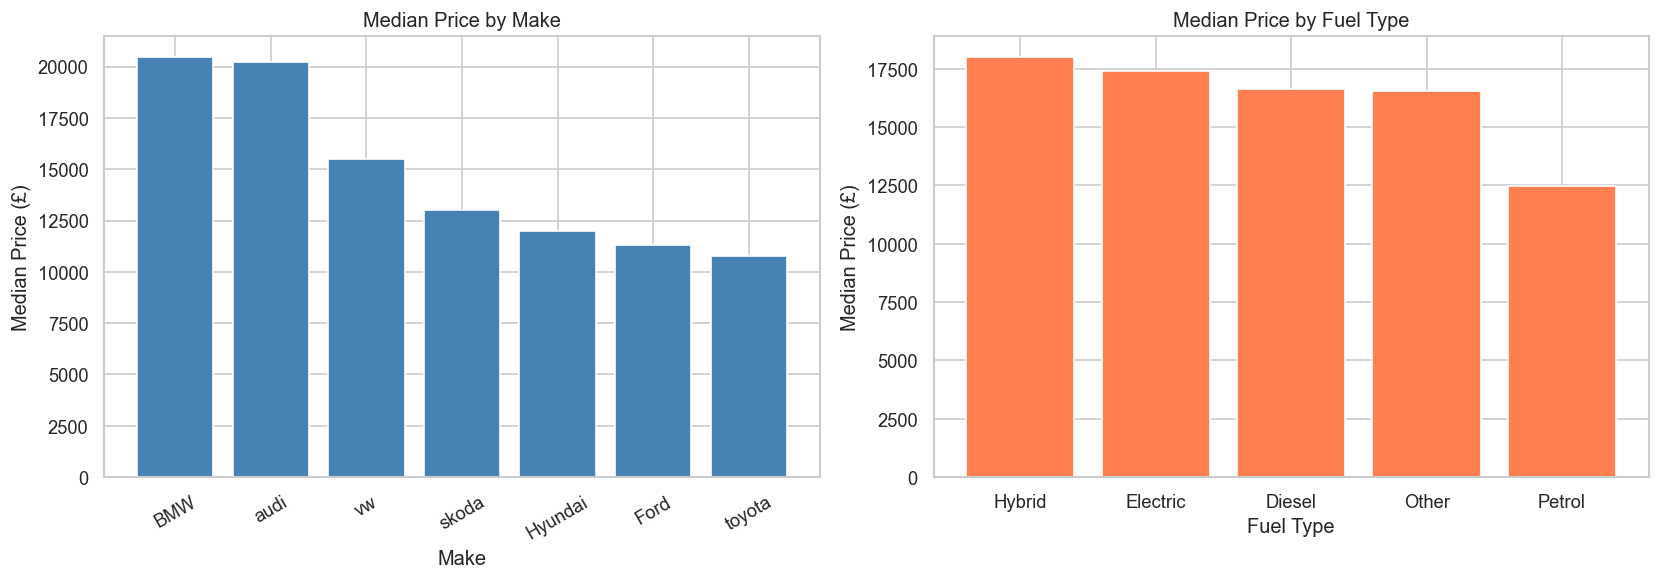

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

make_price = df.groupby('make')['price'].median().sort_values(ascending=False)
axes[0].bar(make_price.index, make_price.values, color='steelblue', edgecolor='white')
axes[0].set_title('Median Price by Make')
axes[0].set_xlabel('Make')
axes[0].set_ylabel('Median Price (\u00a3)')
axes[0].tick_params(axis='x', rotation=30)

fuel_price = df.groupby('fueltype')['price'].median().sort_values(ascending=False)
axes[1].bar(fuel_price.index, fuel_price.values, color='coral', edgecolor='white')
axes[1].set_title('Median Price by Fuel Type')
axes[1].set_xlabel('Fuel Type')
axes[1].set_ylabel('Median Price (\u00a3)')

plt.tight_layout()
plt.show()

---
## Task 2 — Data Preprocessing

###  Dropping rows with missing price (target column)

In [11]:
data = df.copy()

print(f'Rows before: {len(data)}')
data.dropna(subset=['price'], inplace=True)
print(f'Rows after : {len(data)}')

Rows before: 72435
Rows after : 68814


### Fill remaining missing values

In [15]:
# choosing median for numerical features cuz is less effected to outliers , and mode for categorical features.
for col in ['year', 'mileage', 'tax', 'mpg', 'enginesize']:
    med = data[col].median()
    data[col] = data[col].fillna(med)
    
for col in ['model', 'transmission', 'fueltype', 'make']:
    mode_val = data[col].mode()[0]
    data[col] = data[col].fillna(mode_val)

### Outlier Detection & Removal (IQR method)

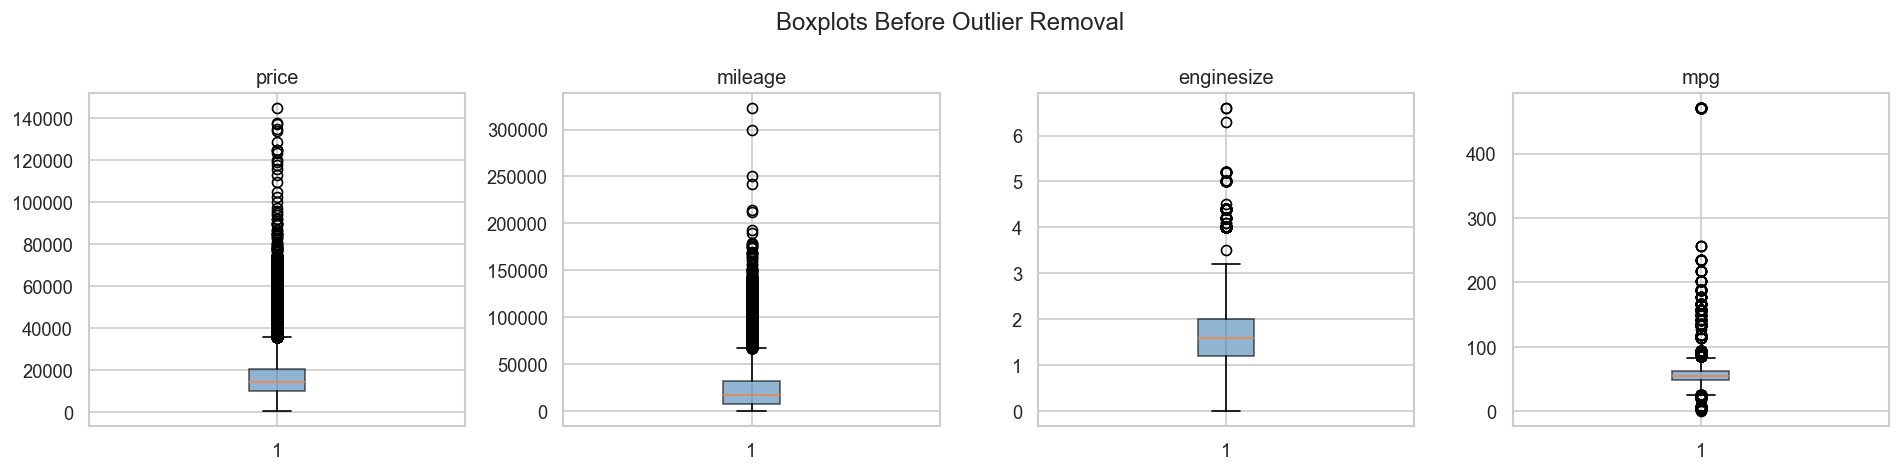

Rows before: 68814
  'price': removed 2573 outliers | bounds [-5121.5, 35648.5]
  'mileage': removed 2976 outliers | bounds [-27340.0, 67900.0]
  'enginesize': removed 74 outliers | bounds [-0.0, 3.2]
  'mpg': removed 768 outliers | bounds [27.6, 83.9]
Rows after : 62423


In [16]:
outlier_cols = ['price', 'mileage', 'enginesize', 'mpg']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, outlier_cols):
    ax.boxplot(data[col], patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax.set_title(col)
plt.suptitle('Boxplots Before Outlier Removal')
plt.tight_layout()
plt.show()

print(f'Rows before: {len(data)}')
for col in outlier_cols:
    Q1  = data[col].quantile(0.25)
    Q3  = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    before = len(data)
    data = data[(data[col] >= lower) & (data[col] <= upper)]
    print(f"  '{col}': removed {before - len(data)} outliers | bounds [{lower:.1f}, {upper:.1f}]")
print(f'Rows after : {len(data)}')

###  Encode Categorical Features

In [17]:
# i used label encoding with features that have hatural order and One-Hot Encoding with features with no order .
trans_order = {'Manual': 0, 'Semi-Auto': 1, 'Automatic': 2, 'Other': 3}
data['transmission'] = data['transmission'].map(trans_order).fillna(0).astype(int)

data = pd.get_dummies(data, columns=['fueltype', 'make', 'model'], drop_first=True)

print(f'Shape after encoding: {data.shape}')

Shape after encoding: (62423, 142)


### Feature Matrix & Scaling

In [19]:
# i used StandardScaler 
X     = data.drop(columns=['price'])
y_reg = data['price']

scaler   = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print(f'Feature matrix shape: {X_scaled.shape}')

Feature matrix shape: (62423, 141)


---
## Create Two Target Variables

### Regression Target

In [21]:
print('Regression target (price):')
print(y_reg.describe())

Regression target (price):
count    62423.000000
mean     15688.741041
std       6802.238291
min        899.000000
25%      10298.000000
50%      14481.000000
75%      19900.000000
max      35600.000000
Name: price, dtype: float64


### Classification Target

Cheap    : price < £11,495
Moderate : £11,495 - £17,600
Expensive: price > £17,600

Class distribution:
price
Expensive    21214
Moderate     20697
Cheap        20512
Name: count, dtype: int64

price
Expensive    34.0%
Moderate     33.2%
Cheap        32.9%
Name: proportion, dtype: object


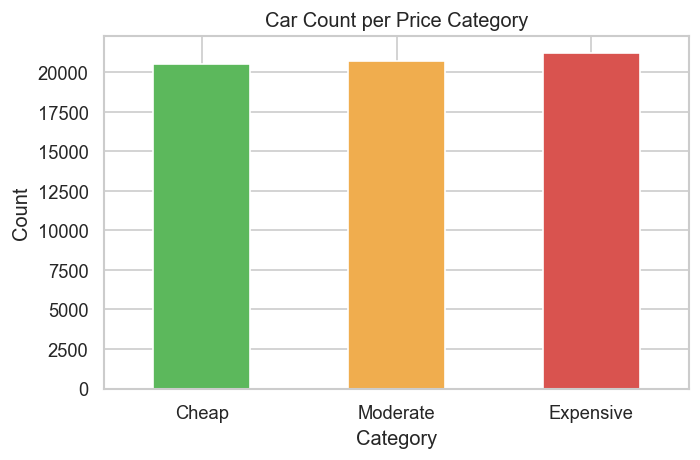

In [22]:
# Each category has third of the data 
q1 = y_reg.quantile(0.33)
q2 = y_reg.quantile(0.66)

print(f'Cheap    : price < \u00a3{q1:,.0f}')
print(f'Moderate : \u00a3{q1:,.0f} - \u00a3{q2:,.0f}')
print(f'Expensive: price > \u00a3{q2:,.0f}')

def price_category(p):
    if p < q1:
        return 'Cheap'
    elif p <= q2:
        return 'Moderate'
    else:
        return 'Expensive'

y_cls = y_reg.apply(price_category)

print('\nClass distribution:')
print(y_cls.value_counts())
print()
print((y_cls.value_counts(normalize=True) * 100).round(1).astype(str).add('%'))

plt.figure(figsize=(6, 4))
y_cls.value_counts()[['Cheap', 'Moderate', 'Expensive']].plot(
    kind='bar', color=['#5cb85c', '#f0ad4e', '#d9534f'], edgecolor='white')
plt.title('Car Count per Price Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

---
## Task 4 — Model 1: Linear Regression

## Train /Test Split (80/20)

In [25]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_scaled, y_reg, test_size=0.2, random_state=42
)
print(f'Train: {X_train_r.shape[0]} rows  |  Test: {X_test_r.shape[0]} rows')

Train: 49938 rows  |  Test: 12485 rows


### Train the Model

In [26]:
lr_model = LinearRegression()
lr_model.fit(X_train_r, y_train_r)
print('Linear Regression trained!')

Linear Regression trained!


###  Evaluate on Test Set

In [30]:
y_pred_r = lr_model.predict(X_test_r)

mae      = mean_absolute_error(y_test_r, y_pred_r)
mse      = mean_squared_error(y_test_r, y_pred_r)
rmse     = np.sqrt(mse)
r2       = r2_score(y_test_r, y_pred_r)
r2_train = r2_score(y_train_r, lr_model.predict(X_train_r))
print('  Linear Regression — Evaluation Metrics \n')
print(f'  MAE      : \u00a3{mae:>10,.2f}')
print(f'  MSE      : \u00a3{mse:>10,.2f}')
print(f'  RMSE     : \u00a3{rmse:>10,.2f}')
print(f'  R\u00b2 Train :  {r2_train:>10.4f}')
print(f'  R\u00b2 Test  :  {r2:>10.4f}')

  Linear Regression — Evaluation Metrics 

  MAE      : £  1,877.44
  MSE      : £6,326,608.16
  RMSE     : £  2,515.27
  R² Train :      0.8675
  R² Test  :      0.8656


### Predicted vs Actual + Residual Plot

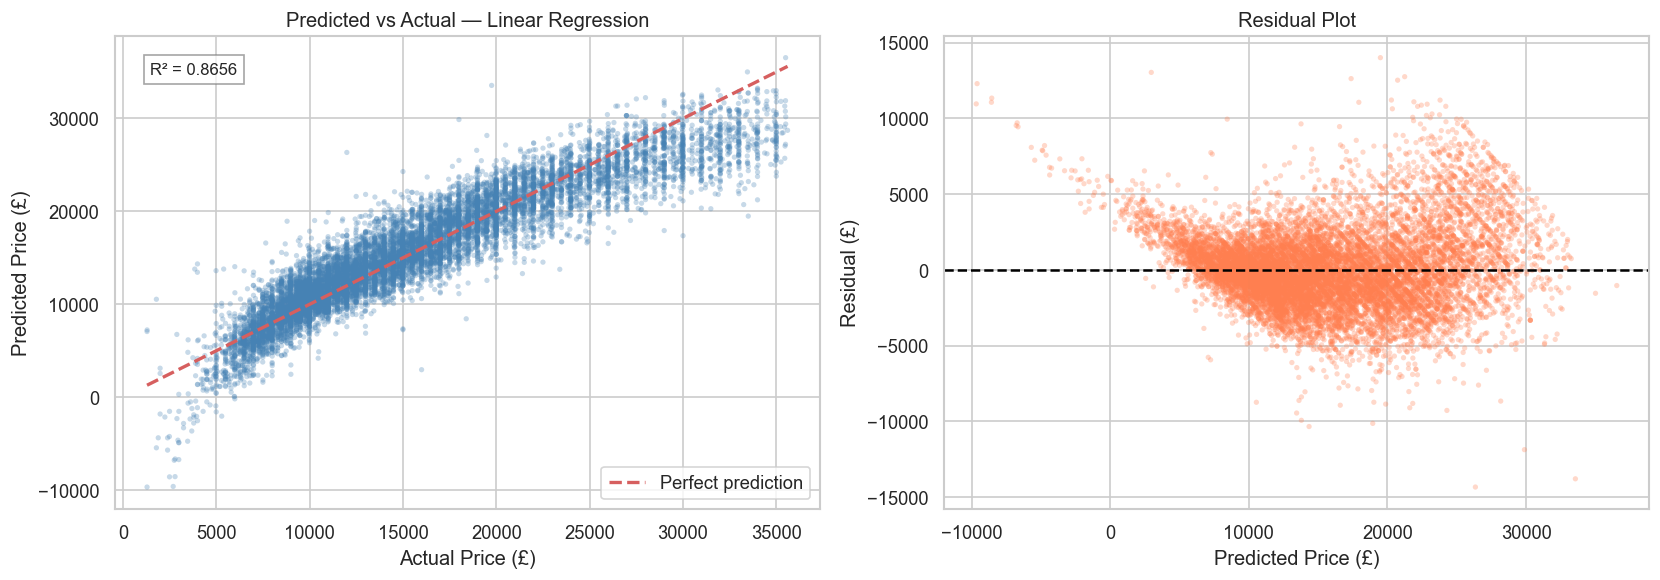

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test_r, y_pred_r, alpha=0.3, color='steelblue', s=10, edgecolors='none')
mn, mx = y_test_r.min(), y_test_r.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Price (\u00a3)')
axes[0].set_ylabel('Predicted Price (\u00a3)')
axes[0].set_title('Predicted vs Actual — Linear Regression')
axes[0].legend()
axes[0].text(0.05, 0.92, f'R\u00b2 = {r2:.4f}', transform=axes[0].transAxes,
             fontsize=10, bbox=dict(facecolor='white', alpha=0.7, edgecolor='grey'))

residuals = y_test_r.values - y_pred_r
axes[1].scatter(y_pred_r, residuals, alpha=0.3, color='coral', s=10, edgecolors='none')
axes[1].axhline(0, color='black', linestyle='--', lw=1.5)
axes[1].set_xlabel('Predicted Price (\u00a3)')
axes[1].set_ylabel('Residual (\u00a3)')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()

### Top Feature Coefficients

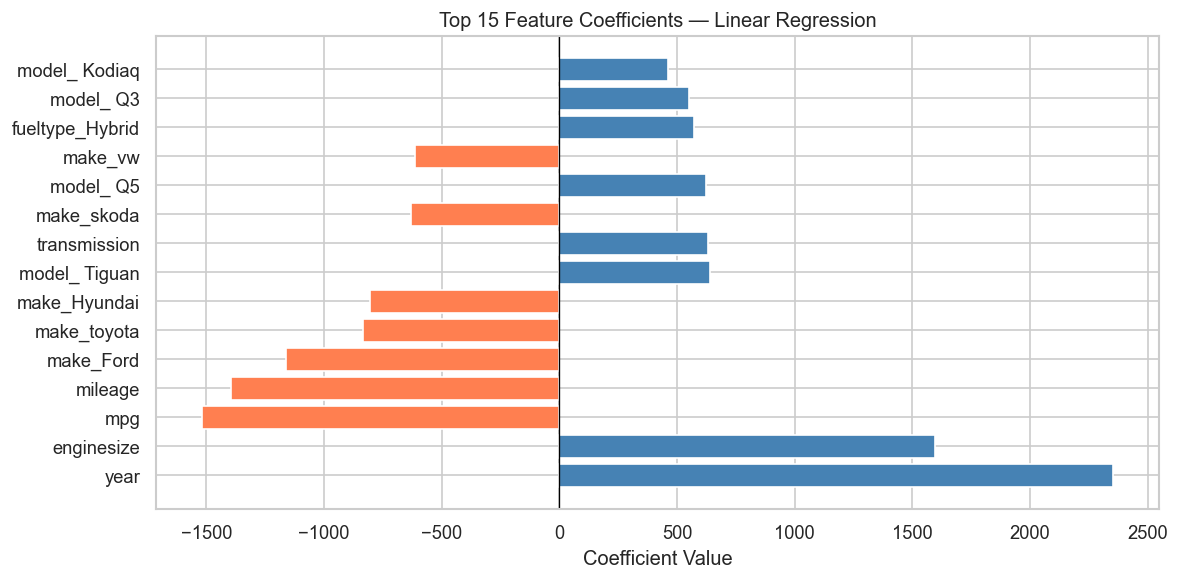

In [34]:
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr_model.coef_})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)
top15   = coef_df.head(15)

plt.figure(figsize=(10, 5))
plt.barh(top15['Feature'],
         top15['Coefficient'],
         color=['steelblue' if c > 0 else 'coral' for c in top15['Coefficient']],
         edgecolor='white')
plt.axvline(0, color='black', lw=0.8)
plt.xlabel('Coefficient Value')
plt.title('Top 15 Feature Coefficients — Linear Regression')
plt.tight_layout()
plt.show()

---
## Task 5 — Model 2: KNN Classification

###  Train / Test Split

In [ ]:
le        = LabelEncoder()
y_cls_enc = le.fit_transform(y_cls)
print('Class mapping:', dict(zip(le.classes_, le.transform(le.classes_))))

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_scaled, y_cls_enc, test_size=0.2, random_state=42, stratify=y_cls_enc
)
print(f'Train: {X_train_c.shape[0]} rows  |  Test: {X_test_c.shape[0]} rows')

### GridSearchCV + KFold to Find Best Parameters

In [ ]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'metric'     : ['euclidean', 'manhattan']
}

kf          = KFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    KNeighborsClassifier(), param_grid,
    cv=kf, scoring='accuracy', n_jobs=-1, verbose=1
)
grid_search.fit(X_train_c, y_train_c)

print(f'\nBest Parameters : {grid_search.best_params_}')
print(f'Best CV Accuracy: {grid_search.best_score_:.4f}')

### GridSearch Results Plot

In [ ]:
results_df = pd.DataFrame(grid_search.cv_results_)

plt.figure(figsize=(10, 5))
for metric in ['euclidean', 'manhattan']:
    mask     = results_df['param_metric'] == metric
    k_vals   = results_df[mask]['param_n_neighbors'].astype(int)
    mean_acc = results_df[mask]['mean_test_score']
    plt.plot(k_vals, mean_acc, marker='o', label=f'metric={metric}')

plt.xlabel('Number of Neighbors (k)')
plt.ylabel('CV Accuracy')
plt.title('KNN GridSearch — Accuracy vs k')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Evaluate Best Model

In [ ]:
best_knn = grid_search.best_estimator_
y_pred_c = best_knn.predict(X_test_c)

acc  = accuracy_score(y_test_c, y_pred_c)
prec = precision_score(y_test_c, y_pred_c, average='weighted')
rec  = recall_score(y_test_c, y_pred_c, average='weighted')
f1   = f1_score(y_test_c, y_pred_c, average='weighted')

print('=' * 45)
print('  KNN Classification — Evaluation Metrics')
print('=' * 45)
print(f'  Accuracy  : {acc:.4f}')
print(f'  Precision : {prec:.4f}  (weighted)')
print(f'  Recall    : {rec:.4f}  (weighted)')
print(f'  F1-Score  : {f1:.4f}  (weighted)')
print('=' * 45)
print()
print('Detailed Classification Report:')
print(classification_report(y_test_c, y_pred_c, target_names=le.classes_))

### Confusion Matrix

In [ ]:
cm = confusion_matrix(y_test_c, y_pred_c)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.5, linecolor='white')
plt.title(f'Confusion Matrix — KNN '
          f'(k={grid_search.best_params_["n_neighbors"]}, '
          f'metric={grid_search.best_params_["metric"]})')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

print('Diagonal = correct predictions | Off-diagonal = misclassifications')

---
## Task 6 — Analysis and Discussion

###  Model Comparison

In [ ]:
print('=' * 55)
print('  Model Comparison')
print('=' * 55)
print(f'  Linear Regression : R\u00b2={r2:.4f} | RMSE=\u00a3{rmse:,.0f} | MAE=\u00a3{mae:,.0f}')
print(f'  KNN Classification: Accuracy={acc:.4f} | F1={f1:.4f}')
print()
print("""
  Discussion:
  - 'Better' depends on context:
      Regression    -> lower RMSE/MAE and higher R\u00b2 is better.
      Classification -> higher Accuracy/F1 is better.

  - Classification is generally easier because the model only needs
    to predict one of 3 buckets, not an exact price. A prediction off
    by a few hundred pounds still lands in the correct category.

  - Converting price to categories DOES lose information. A car worth
    \u00a39,999 and one worth \u00a35,000 may both fall into 'Cheap' even
    though their values differ significantly.
""")

### Sensitivity Analysis
#### A) Remove the Most Correlated Feature

In [ ]:
num_feats       = ['year', 'mileage', 'tax', 'mpg', 'enginesize']
corr_with_price = X_scaled[num_feats].corrwith(y_reg.reset_index(drop=True)).abs()
top_feat        = corr_with_price.idxmax()

print(f'Most correlated feature: "{top_feat}" (r={corr_with_price[top_feat]:.4f})')

X_no_top = X_scaled.drop(columns=[top_feat])
Xtr, Xte, ytr, yte = train_test_split(X_no_top, y_reg, test_size=0.2, random_state=42)
r2_no_top = r2_score(yte, LinearRegression().fit(Xtr, ytr).predict(Xte))

print(f'R\u00b2 WITH    "{top_feat}": {r2:.4f}')
print(f'R\u00b2 WITHOUT "{top_feat}": {r2_no_top:.4f}')
print(f'Change: {r2_no_top - r2:+.4f}')
print('A notable drop confirms this feature carries real predictive signal.')

#### B) KNN Without Scaling

In [ ]:
best_k      = grid_search.best_params_['n_neighbors']
best_metric = grid_search.best_params_['metric']

Xtr_u, Xte_u, ytr_u, yte_u = train_test_split(
    X, y_cls_enc, test_size=0.2, random_state=42, stratify=y_cls_enc
)
knn_unscaled = KNeighborsClassifier(n_neighbors=best_k, metric=best_metric)
knn_unscaled.fit(Xtr_u, ytr_u)
acc_unscaled = accuracy_score(yte_u, knn_unscaled.predict(Xte_u))

print(f'Accuracy WITH    scaling: {acc:.4f}')
print(f'Accuracy WITHOUT scaling: {acc_unscaled:.4f}')
print(f'Performance drop        : {acc - acc_unscaled:+.4f}')
print()
print('Without scaling, mileage (large range) dominates the distance')
print('calculation, causing a significant drop in accuracy.')

#### C) Different Price Category Thresholds

In [ ]:
threshold_tests = [
    (y_reg.quantile(0.25), y_reg.quantile(0.75), 'Q1/Q3 split'),
    (q1,                   q2,                   'Tertile split (original)'),
    (10_000,               20_000,               'Fixed: 10k / 20k'),
]

print(f'{"Threshold":<30} {"Accuracy":>10}')
print('-' * 42)
for low, high, label in threshold_tests:
    y_tmp = y_reg.apply(lambda p: 0 if p < low else (1 if p <= high else 2))
    Xt, Xe, yt, ye = train_test_split(
        X_scaled, y_tmp, test_size=0.2, random_state=42, stratify=y_tmp
    )
    knn_tmp = KNeighborsClassifier(n_neighbors=best_k, metric=best_metric)
    knn_tmp.fit(Xt, yt)
    print(f'{label:<30} {accuracy_score(ye, knn_tmp.predict(Xe)):>10.4f}')

print()
print('Balanced thresholds (tertile) give the most honest evaluation.')

---
## Task 7 — Additional Visualizations

### Extra Plot 1 — Price vs Mileage
Shows the negative relationship between mileage and price — a key predictor.

In [ ]:
plt.figure(figsize=(10, 5))
plt.scatter(data['mileage'], y_reg, alpha=0.15, s=5, color='steelblue', label='Cars')

z      = np.polyfit(data['mileage'], y_reg, 1)
p_line = np.poly1d(z)
x_line = np.linspace(data['mileage'].min(), data['mileage'].max(), 200)
plt.plot(x_line, p_line(x_line), 'r--', lw=2, label='Trend line')

plt.xlabel('Mileage')
plt.ylabel('Price (\u00a3)')
plt.title('Price vs Mileage — Clear Negative Trend')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Extra Plot 2 — Median Price by Year
Confirms that newer cars are consistently priced higher — year is one of the strongest predictors.

In [ ]:
year_price = data.groupby('year')['price'].median().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(year_price['year'], year_price['price'],
         marker='o', color='steelblue', linewidth=2, markersize=6)
plt.fill_between(year_price['year'], year_price['price'], alpha=0.1, color='steelblue')
plt.xlabel('Year')
plt.ylabel('Median Price (\u00a3)')
plt.title('Median Price by Year — Newer Cars Cost More')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Final Summary

In [ ]:
print('=' * 55)
print('  FINAL SUMMARY')
print('=' * 55)
print(f'  Dataset rows (after cleaning) : {len(data)}')
print(f'  Number of features            : {X.shape[1]}')
print()
print('  Linear Regression')
print(f'    MAE    : \u00a3{mae:>10,.2f}')
print(f'    RMSE   : \u00a3{rmse:>10,.2f}')
print(f'    R\u00b2 Test:  {r2:>10.4f}')
print()
print('  KNN Classification')
print(f'    Best k      : {grid_search.best_params_["n_neighbors"]}')
print(f'    Best metric : {grid_search.best_params_["metric"]}')
print(f'    Accuracy    : {acc:.4f}')
print(f'    F1-Score    : {f1:.4f}  (weighted)')
print('=' * 55)

## Thank YOU___________________________________________________________________________________________________________________________________________